# Wilcoxon signed-rank test (paired samples)

                   n  mean_diff   ci_low  ci_high      F  df_error  partial_eta2  p_uncorrected  p_fwer_maxT     p_text stars
bif_period        20     0.2453   0.1169   0.3928   11.6        19        0.3791      0.0001221     0.009657  p = 0.010    **
bif_task          20     0.1733  0.07662    0.283  9.988        19        0.3446      0.0008545      0.02316  p = 0.023     *
bif_interaction   20     0.1736 -0.02039   0.3704  2.918        19        0.1331         0.1093       0.4599  p = 0.460    ns
meta_period       20     0.4632   0.3244   0.5962  43.92        19         0.698      5.722e-06    5.722e-06  p < 0.001   ***
meta_task         20     0.1257  0.02002   0.2341   5.06        19        0.2103        0.03571       0.1751  p = 0.175    ns
meta_interaction  20   -0.04153  -0.2491   0.1658 0.1483        19      0.007743         0.7016       0.9979  p = 0.998    ns


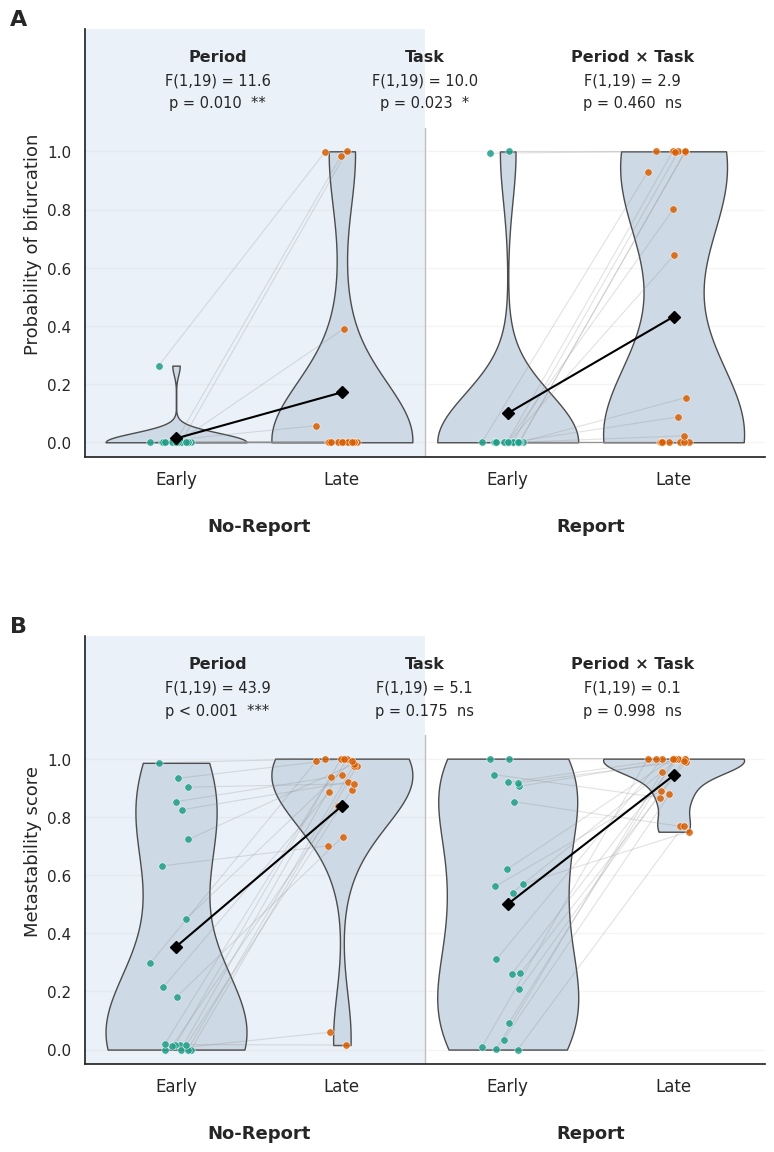

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================
repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
output_dir = repo_root
conditions = [("Passive", "early"), ("Passive", "late"), ("Active", "early"), ("Active", "late")]
order = conditions
map_task = {"Active": "Report", "Passive": "No-Report"}
POS = {("Passive", "early"): 0, ("Passive", "late"): 1, ("Active", "early"): 2, ("Active", "late"): 3}

N_PERMUTATIONS = 200000   # used only if n_subjects > EXACT_MAX_N
EXACT_MAX_N = 20          # exact enumeration of all 2^n sign flips up to this n
SEED = 42

COND_COLOR = {"early": "#1f9e89", "late": "#d95f02"}
VIOLIN_FILL = "#c9d9e8"
C_HILITE = "#eaf1f8"

MEASURES = {"bif": ("bifurcation_prob", "Probability of bifurcation", "A"),
            "meta": ("metastability_score", "Metastability score", "B")}
CELLS = [("Passive", "early"), ("Passive", "late"), ("Active", "early"), ("Active", "late")]
EFFECTS = {"period":      ([-0.5,  0.5, -0.5, 0.5], "Period"),
           "task":        ([-0.5, -0.5,  0.5, 0.5], "Task"),
           "interaction": ([ 1.0, -1.0, -1.0, 1.0], "Period × Task")}


def load_metabif_data():
    dfs = []
    for task, period in conditions:
        csv_path = repo_root / f"Fit_{task}_{period}" / "MetaBifurc_AllModels_21^2" / "metabifurc.csv"
        df = pd.read_csv(csv_path, index_col=0).copy()
        if "probability_of_bifurcation" in df.columns:
            df = df.rename(columns={"probability_of_bifurcation": "bifurcation_prob"})
        for col in ["bifurcation_prob", "metastability_score"]:
            if col not in df.columns:
                raise ValueError(f"Missing {col} column in {csv_path}")
            if df[col].isna().any():
                raise ValueError(f"NaNs found in {col} in {csv_path}")
        df["SubID"] = df.index.astype(str)
        df["task"] = task
        df["period"] = period
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)


# ============================================================
# STATS: 2x2 within-subject factorial via sign-flip permutation (studentized),
#        maxT over 3 effects x 2 measures
# ============================================================
def factorial_contrasts(df, value_col):
    w = df.pivot_table(index="SubID", columns=["task", "period"], values=value_col)[CELLS].dropna()
    return pd.DataFrame({k: w.to_numpy() @ np.asarray(wts) for k, (wts, _) in EFFECTS.items()}, index=w.index)


def _sign_blocks(n, n_permutations, seed, exact_max_n, block=65536):
    if n <= exact_max_n:
        total = 2 ** n
        bits = np.arange(n)
        for start in range(0, total, block):
            idx = np.arange(start, min(start + block, total))[:, None]
            yield 1.0 - 2.0 * ((idx >> bits) & 1)
    else:
        rng = np.random.default_rng(seed)
        for start in range(0, n_permutations, block):
            s = rng.choice([-1.0, 1.0], size=(min(block, n_permutations - start), n))
            if start == 0:
                s[0] = 1.0
            yield s


def _t_stat(m, ss, n):
    var = np.maximum(ss / n - m ** 2, 0.0) * n / (n - 1)
    with np.errstate(divide="ignore", invalid="ignore"):
        t = np.abs(m) * np.sqrt(n) / np.sqrt(var)
    t[np.isclose(m, 0.0)] = 0.0
    return t


def signflip_maxt(contrasts, n_permutations=N_PERMUTATIONS, seed=SEED, exact_max_n=EXACT_MAX_N):
    D = contrasts.to_numpy(dtype=float)
    n = D.shape[0]
    ss = (D ** 2).sum(0)
    obs = _t_stat(D.mean(0), ss, n) * (1 - 1e-9)
    hits_unc = np.zeros(D.shape[1])
    hits_max = np.zeros(D.shape[1])
    total = 0
    for S in _sign_blocks(n, n_permutations, seed, exact_max_n):
        null = _t_stat(S @ D / n, ss, n)
        hits_unc += (null >= obs).sum(0)
        hits_max += (null.max(1)[:, None] >= obs).sum(0)
        total += S.shape[0]
    return pd.DataFrame({"n": n, "exact": n <= exact_max_n, "n_signflips": total,
                         "mean_diff": D.mean(0), "t": _t_stat(D.mean(0), ss, n),
                         "p_uncorrected": hits_unc / total,
                         "p_fwer_maxT": hits_max / total}, index=contrasts.columns)


def bootstrap_ci(contrasts, n_boot=10000, seed=SEED, alpha=0.05):
    D = contrasts.to_numpy(dtype=float)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, D.shape[0], size=(n_boot, D.shape[0]))
    boots = D[idx].mean(1)
    lo, hi = np.percentile(boots, [100 * alpha / 2, 100 * (1 - alpha / 2)], axis=0)
    return pd.DataFrame({"ci_low": lo, "ci_high": hi}, index=contrasts.columns)


def run_family(data):
    parts = [factorial_contrasts(data, col).add_prefix(f"{key}_") for key, (col, _, _) in MEASURES.items()]
    c = pd.concat(parts, axis=1, join="inner")
    out = pd.concat([signflip_maxt(c), bootstrap_ci(c)], axis=1)
    out["F"] = out["t"] ** 2
    out["df_error"] = out["n"] - 1
    out["partial_eta2"] = out["F"] / (out["F"] + out["df_error"])
    out["p_text"] = out["p_fwer_maxT"].map(format_p)
    out["stars"] = out["p_fwer_maxT"].map(p_to_stars)
    return out


def p_to_stars(p):
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def format_p(p):
    return "p < 0.001" if p < 1e-3 else f"p = {p:.3f}"


# ============================================================
# PANEL
# ============================================================
def plot_panel(ax, df, value_col, y_label, panel_letter, effect_stats):
    cond_vals = {(t, p): df[(df.task == t) & (df.period == p)].set_index("SubID")[value_col]
                 for (t, p) in conditions}

    rng = np.random.default_rng(SEED)
    subject_ids = sorted(df["SubID"].astype(str).unique())
    jitter_by_subject = dict(zip(subject_ids, rng.normal(0.0, 0.08, size=len(subject_ids))))

    ax.set_xlim(-0.55, 3.55)
    ax.axvspan(-0.55, 1.5, color=C_HILITE, lw=0, zorder=0)

    violin_arrays = []
    for key in order:
        v = cond_vals[key].to_numpy().astype(float)
        violin_arrays.append(v + np.linspace(-1e-9, 1e-9, len(v)))
    sns.violinplot(data=violin_arrays, inner=None, cut=0, density_norm="width",
                   width=0.85, bw_adjust=1.0, linewidth=1.0, ax=ax, color=VIOLIN_FILL)

    for task in ["Passive", "Active"]:
        e = cond_vals[(task, "early")]
        l = cond_vals[(task, "late")]
        xe, xl = POS[(task, "early")], POS[(task, "late")]
        for subject_id in e.index.intersection(l.index):
            offset = jitter_by_subject[str(subject_id)]
            ax.plot([xe + offset, xl + offset], [e[subject_id], l[subject_id]],
                    color="0.55", alpha=0.25, lw=0.8, zorder=1)

    for key in order:
        values = cond_vals[key]
        xj = [POS[key] + jitter_by_subject[str(s)] for s in values.index]
        ax.scatter(xj, values.to_numpy(), s=28, alpha=0.85, color=COND_COLOR[key[1]],
                   edgecolors="white", linewidths=0.4, zorder=3)

    for task in ["Passive", "Active"]:
        xe, xl = POS[(task, "early")], POS[(task, "late")]
        me = cond_vals[(task, "early")].mean()
        ml = cond_vals[(task, "late")].mean()
        ax.plot([xe, xl], [me, ml], color="black", marker="D", markersize=6, linewidth=1.5, zorder=4)

    for x, (key, (_, label)) in zip([0.25, 1.5, 2.75], EFFECTS.items()):
        r = effect_stats[key]
        ax.text(x, 1.30, label, ha="center", va="bottom", fontsize=11.5, fontweight="bold")
        ax.text(x, 1.22, f"F(1,{int(r['df_error'])}) = {r['F']:.1f}", ha="center", va="bottom", fontsize=10.5)
        ax.text(x, 1.14, f"{r['p_text']}  {r['stars']}", ha="center", va="bottom", fontsize=10.5)
    ax.set_ylim(-0.05, 1.42)
    ax.set_xlim(-0.55, 3.55)
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.axvline(1.5, ymax=(1.08 + 0.05) / 1.47, color="0.75", lw=1.0, zorder=0)
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(["Early", "Late", "Early", "Late"], fontsize=12)
    ax.set_ylabel(y_label, fontsize=13)
    ax.grid(axis="y", alpha=0.2)
    sns.despine(ax=ax)

    ax.text(0.5, -0.14, map_task["Passive"], transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=13, fontweight="bold", clip_on=False)
    ax.text(2.5, -0.14, map_task["Active"], transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=13, fontweight="bold", clip_on=False)
    ax.text(-0.11, 1.0, panel_letter, transform=ax.transAxes,
            ha="left", va="bottom", fontsize=16, fontweight="bold")


def build_figure(data, out_stem="Bifurcation_Metastability_Factorial"):
    stats = run_family(data)
    fig, axes = plt.subplots(2, 1, figsize=(8, 11.5))
    fig.subplots_adjust(hspace=0.42, left=0.11, right=0.96, top=0.97, bottom=0.07)
    for ax, (key, (col, label, letter)) in zip(axes, MEASURES.items()):
        effect_stats = {e: stats.loc[f"{key}_{e}"] for e in EFFECTS}
        plot_panel(ax, data, col, label, letter, effect_stats)
    cols = ["n", "mean_diff", "ci_low", "ci_high", "F", "df_error", "partial_eta2",
            "p_uncorrected", "p_fwer_maxT", "p_text", "stars"]
    with pd.option_context("display.width", 200, "display.max_columns", 20, "display.float_format", "{:.4g}".format):
        print(stats[cols])
    stats.to_csv(output_dir / f"{out_stem}_stats.csv")
    fig.savefig(output_dir / f"{out_stem}.png", dpi=300, bbox_inches="tight")
    fig.savefig(output_dir / f"{out_stem}.pdf", bbox_inches="tight")
    return fig, stats


# ============================================================
# RUN
# ============================================================
if __name__ == "__main__":
    metabif_data = load_metabif_data()
    fig, stats = build_figure(metabif_data)
    plt.show()

In [8]:
SIMPLE_EFFECTS = {
    "late_vs_early_report":     ([ 0.0,  0.0, -1.0, 1.0], "Late − Early | Report"),
    "late_vs_early_noreport":   ([-1.0,  1.0,  0.0, 0.0], "Late − Early | No-Report"),
    "report_vs_noreport_early": ([-1.0,  0.0,  1.0, 0.0], "Report − No-Report | Early"),
    "report_vs_noreport_late":  ([ 0.0, -1.0,  0.0, 1.0], "Report − No-Report | Late"),
}


def simple_contrasts(df, value_col):
    w = df.pivot_table(index="SubID", columns=["task", "period"], values=value_col)[CELLS].dropna()
    c = pd.DataFrame({k: w.to_numpy() @ np.asarray(wts) for k, (wts, _) in SIMPLE_EFFECTS.items()}, index=w.index)
    return c, w


def run_simple_effects(data):
    stats_list, cells_list = [], []
    for key, (col, label, _) in MEASURES.items():
        c, w = simple_contrasts(data, col)
        out = pd.concat([signflip_maxt(c), bootstrap_ci(c)], axis=1)
        out["t_signed"] = np.sign(out["mean_diff"]) * out["t"]
        out["df"] = out["n"] - 1
        out["dz"] = out["t_signed"] / np.sqrt(out["n"])
        out["n_pos"] = (c > 0).sum()
        out["n_neg"] = (c < 0).sum()
        out["n_zero"] = (c == 0).sum()
        out["p_text"] = out["p_fwer_maxT"].map(format_p)
        out["stars"] = out["p_fwer_maxT"].map(p_to_stars)
        out.insert(0, "contrast", [SIMPLE_EFFECTS[k][1] for k in out.index])
        out.index = pd.MultiIndex.from_product([[key], out.index], names=["measure", "effect"])
        stats_list.append(out)

        cells = pd.DataFrame({"mean": w.mean(), "sd": w.std(ddof=1), "n_nonzero": (w > 0).sum(), "n": w.count()})
        cells.index = pd.MultiIndex.from_tuples([(key, map_task[t], p) for t, p in cells.index],
                                                names=["measure", "task", "period"])
        cells_list.append(cells)
    return pd.concat(stats_list), pd.concat(cells_list)


simple_stats, cell_summary = run_simple_effects(metabif_data)

cols = ["contrast", "n", "mean_diff", "ci_low", "ci_high", "t_signed", "df", "dz",
        "n_pos", "n_neg", "n_zero", "p_uncorrected", "p_fwer_maxT", "stars"]
with pd.option_context("display.width", 220, "display.max_columns", 30, "display.float_format", "{:.4g}".format):
    print("Cell summary\n", cell_summary, "\n")
    print("Simple effects — sign-flip permutation, maxT within each measure (family of 4)\n", simple_stats[cols])

print()
for (key, _), r in simple_stats.iterrows():
    print(f"[{key}] {r['contrast']}: Δ = {r['mean_diff']:.3f}, 95% CI [{r['ci_low']:.3f}, {r['ci_high']:.3f}], "
          f"t({int(r['df'])}) = {r['t_signed']:.2f}, {r['p_text']} (maxT-corrected, 4 tests); "
          f"{int(r['n_pos'])}/{int(r['n'])} participants positive, {int(r['n_zero'])} ties")

# simple_stats.to_csv(output_dir / "Bifurcation_Metastability_SimpleEffects_stats.csv")
# cell_summary.to_csv(output_dir / "Bifurcation_Metastability_CellSummary.csv")

Cell summary
                             mean      sd  n_nonzero   n
measure task      period                               
bif     No-Report early  0.01317 0.05889          1  20
                  late    0.1717  0.3648         10  20
        Report    early  0.09964  0.3067          2  20
                  late    0.4317  0.4712         13  20
meta    No-Report early   0.3534  0.3875         17  20
                  late    0.8374  0.2865         20  20
        Report    early      0.5  0.3785         20  20
                  late    0.9424  0.0893         20  20 

Simple effects — sign-flip permutation, maxT within each measure (family of 4)
                                                     contrast   n  mean_diff   ci_low  ci_high  t_signed  df     dz  n_pos  n_neg  n_zero  p_uncorrected  p_fwer_maxT stars
measure effect                                                                                                                                                            
bi

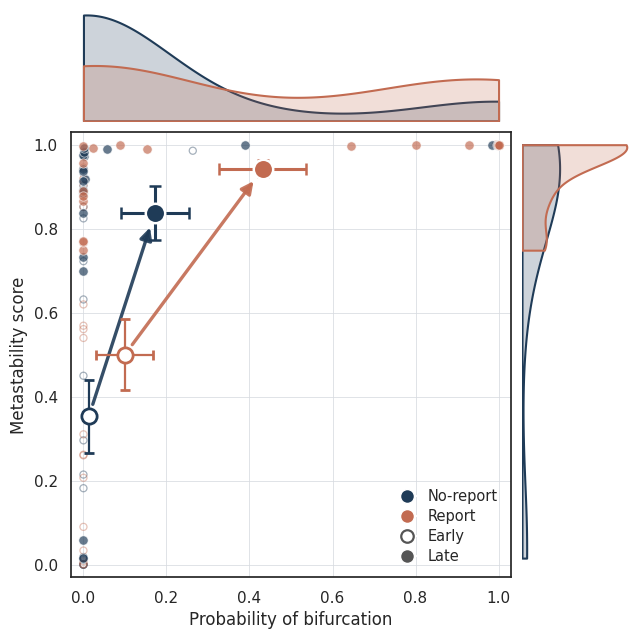

In [4]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from pathlib import Path

repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
conditions = [("Passive", "early"), ("Passive", "late"), ("Active", "early"), ("Active", "late")]
map_task = {"Passive": "no-report", "Active": "report"}

C_NR = "#1f3b57"
C_RP = "#c26b51"
C_SEP = "#d7dbe0"

_avail = {f.name for f in font_manager.fontManager.ttflist}
_fam = next((f for f in ["Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"] if f in _avail), "DejaVu Sans")
mpl.rcParams.update({
    "font.family": _fam, "font.size": 11,
    "axes.linewidth": 1.0, "axes.edgecolor": "#2b2b2b",
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
})


def load_metabif_data():
    dfs = []
    for task, period in conditions:
        csv_path = repo_root / f"Fit_{task}_{period}" / "MetaBifurc_AllModels_21^2" / "metabifurc.csv"
        data = pd.read_csv(csv_path, index_col=0).copy()
        if "probability_of_bifurcation" in data.columns:
            data = data.rename(columns={"probability_of_bifurcation": "bifurcation_prob"})
        if "bifurcation_prob" not in data.columns:
            raise ValueError(f"Missing bifurcation column in {csv_path}")
        if "metastability_score" not in data.columns:
            raise ValueError(f"Missing metastability_score column in {csv_path}")
        data["bifurcation_prob"] = data["bifurcation_prob"].fillna(0)
        data["SubID"] = data.index.astype(str)
        data["task"] = task
        data["period"] = period
        data["task_plot"] = data["task"].map(map_task)
        data["condition_plot"] = data["task_plot"] + "-" + data["period"]
        dfs.append(data)
    return pd.concat(dfs, ignore_index=True)


def _subject_frame(bif, meta, period):
    b = bif[bif.period == period][["SubID", "task", "bifurcation_prob"]]
    m = meta[meta.period == period][["SubID", "task", "metastability_score"]]
    j = b.merge(m, on=["SubID", "task"], how="inner")
    j["cond"] = j["task"].map(map_task)
    return j


def build_jointscatter(bif, meta, out_stem="Idea2_JointScatter"):
    sns.set_theme(style="white")
    late = _subject_frame(bif, meta, "late")
    early = _subject_frame(bif, meta, "early")
    pal = {"no-report": C_NR, "report": C_RP}

    fig = plt.figure(figsize=(6.6, 6.6))
    gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                  hspace=0.04, wspace=0.04, left=0.12, right=0.97, top=0.97, bottom=0.11)
    ax = fig.add_subplot(gs[1, 0])
    ax_top = fig.add_subplot(gs[0, 0], sharex=ax)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax)

    def centroid(data, cond):
        subset = data[data.cond == cond]
        return (subset["bifurcation_prob"].mean(), subset["metastability_score"].mean(),
                subset["bifurcation_prob"].sem(), subset["metastability_score"].sem())

    for cond, color in pal.items():
        late_data = late[late.cond == cond]
        early_data = early[early.cond == cond]

        ax.scatter(early_data["bifurcation_prob"], early_data["metastability_score"],
                   s=26, alpha=0.40, facecolors="none", edgecolors=color, linewidth=0.9, zorder=2)
        ax.scatter(late_data["bifurcation_prob"], late_data["metastability_score"],
                   s=45, alpha=0.68, color=color, edgecolor="white", linewidth=0.6, zorder=3)

        early_x, early_y, early_sx, early_sy = centroid(early, cond)
        late_x, late_y, late_sx, late_sy = centroid(late, cond)
        ax.annotate("", xy=(late_x, late_y), xytext=(early_x, early_y),
                    arrowprops=dict(arrowstyle="-|>", color=color, lw=2.4, alpha=0.9,
                                    shrinkA=9, shrinkB=11, mutation_scale=18), zorder=4)
        ax.errorbar(early_x, early_y, xerr=early_sx, yerr=early_sy, fmt="o", color=color,
                    markerfacecolor="white", markeredgecolor=color, markeredgewidth=2.0,
                    markersize=11, capsize=3.5, capthick=1.3, elinewidth=1.6, zorder=5)
        ax.errorbar(late_x, late_y, xerr=late_sx, yerr=late_sy, fmt="o", color=color,
                    markerfacecolor=color, markeredgecolor="white", markeredgewidth=1.8,
                    markersize=14, capsize=4, capthick=1.5, elinewidth=2.2, zorder=6)

        sns.kdeplot(x=late_data["bifurcation_prob"], ax=ax_top, color=color, fill=True,
                    alpha=0.22, lw=1.5, cut=0, bw_adjust=1.0)
        sns.kdeplot(y=late_data["metastability_score"], ax=ax_right, color=color, fill=True,
                    alpha=0.22, lw=1.5, cut=0, bw_adjust=1.0)

    ax.set_xlim(-0.03, 1.03)
    ax.set_ylim(-0.03, 1.03)
    ax.set_xlabel("Probability of bifurcation", fontsize=12)
    ax.set_ylabel("Metastability score", fontsize=12)
    ax.grid(color=C_SEP, alpha=0.8, lw=0.7)
    ax.set_axisbelow(True)

    for marginal_ax in (ax_top, ax_right):
        marginal_ax.set_axis_off()

    handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=C_NR, markersize=10, label="No-report"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor=C_RP, markersize=10, label="Report"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="none", markeredgecolor="#555",
               markeredgewidth=1.6, markersize=9, label="Early"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#555", markersize=10, label="Late"),
    ]
    ax.legend(handles=handles, loc="lower right", frameon=False, fontsize=10.5,
              ncol=1, handletextpad=0.4, labelspacing=0.35)
    fig.savefig(repo_root / f"{out_stem}.pdf", bbox_inches="tight")
    fig.savefig(repo_root / f"{out_stem}.png", dpi=600, bbox_inches="tight")
    return fig


# ---------- data loading ----------
def _load():
    metabif_data = load_metabif_data()
    bif = metabif_data[["SubID", "task", "period", "bifurcation_prob"]].copy()
    meta = metabif_data[["SubID", "task", "period", "metastability_score"]].copy()
    return bif, meta


if __name__ == "__main__":
    bif, meta = _load()
    build_jointscatter(bif, meta)
    plt.show()
